# The spell mini-language

A "spell" compresses a whole processing chain into one string, so a diagnostic can
live in a config file or a plot title.

```
[alias ~] variable[.isel(...)][|modifiers] : temporal : spatial
```

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
from x4c import Spell

case = x4c.Timeseries(case_dir, grid_dict={'atm': 'ne16np4', 'ocn': 'g16'},
                      cesm_ver=1)

>>> case.root_dir: /glade/u/home/fengzhu/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["ice"]["cice.h"] created


## Parsing

A `Spell` is parsed, not evaluated. Arguments are read with a restricted parser that
accepts numbers, strings, containers and `slice(...)` — and nothing else — so a spell
from an untrusted config cannot execute code.

In [3]:
S = Spell('GMST ~ TS:ann:gm')
print(S)
print()
print('alias      :', S.alias)
print('variable   :', S.vn)
print('temporal   :', S.ann_method)
print('spatial    :', S.sa_method)

Spell(vn='TS', alias='GMST', ann_method='ann', sa_method='gm')

alias      : GMST
variable   : TS
temporal   : ann
spatial    : gm


In [4]:
S = Spell('T.isel(lev=-1)|regrid(2,2)|plev(500,850):climo:zm')
for f in ['vn', 'slicing_method', 'slicing_kwargs', 'regrid_args',
          'plev_levels', 'ann_method', 'sa_method']:
    print(f'{f:16s} {getattr(S, f)!r}')

vn               'T'
slicing_method   'isel'
slicing_kwargs   {'lev': -1}
regrid_args      (2, 2)
plev_levels      [500, 850]
ann_method       'climo'
sa_method        'zm'


Malformed spells fail at parse time, naming the spell, rather than part-way
through a long computation.

In [5]:
for bad in ['TS:ann:gm:extra', 'TS:ann:not_a_method', 'TS|regrid(open("x")):ann']:
    try:
        Spell(bad)
    except ValueError as e:
        print(f'{bad:38s} -> {str(e)[:80]}')

TS:ann:gm:extra                        -> Cannot parse spell `TS:ann:gm:extra`: expected at most 3 colon-separated fields 
TS:ann:not_a_method                    -> Unknown spatial average method `not_a_method` in spell `TS:ann:not_a_method`. Op
TS|regrid(open("x")):ann               -> Cannot call `open` in `regrid(open("x"))`: the only callable allowed in a spell 


## Computing a spell

`case.calc(spell)` runs the chain and caches the result under `case.diags[spell]`.

In [6]:
gmst = case.calc('GMST ~ TS:ann:gm', timespan=(1, 10))
print(dict(gmst.sizes))
print(np.round(gmst.values, 3))

>>> case.ds["TS"] created
>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


>>> case.diags["GMST"] created
{'time': 10}
[23.245 23.204 23.358 23.354 23.065 23.123 23.237 23.367 23.025 22.849]


Note the units: `calc` converts a field tagged `K` to degrees Celsius.

In [7]:
print('name :', gmst.name)
print('units:', gmst.attrs.get('units'))
print('cached under:', [k for k in case.diags])

name : GMST
units: °C
cached under: ['GMST']


## A few spells at once

This is where the notation pays off — a diagnostics suite becomes a dictionary.

In [8]:
spells = {
    'GMST': 'TS:ann:gm',
    'GMPRECT': 'PRECT:ann:gm',
    'RESTOM': 'RESTOM:ann:gm',
    'NHICE': 'ICEFRAC:ann:nhm',
}
for key, spell in spells.items():
    case.calc(spell, timespan=(1, 10), verbose=False)
    print(f'{key:8s} {spell:22s} -> {np.round(case.diags[spell].values, 3)}')

>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


GMST     TS:ann:gm              -> [23.245 23.204 23.358 23.354 23.065 23.123 23.237 23.367 23.025 22.849]


>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


GMPRECT  PRECT:ann:gm           -> [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


RESTOM   RESTOM:ann:gm          -> [ 0.146 -0.118  0.254  0.269  0.863  1.29   0.425  0.753  0.097  1.095]


>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


NHICE    ICEFRAC:ann:nhm        -> [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


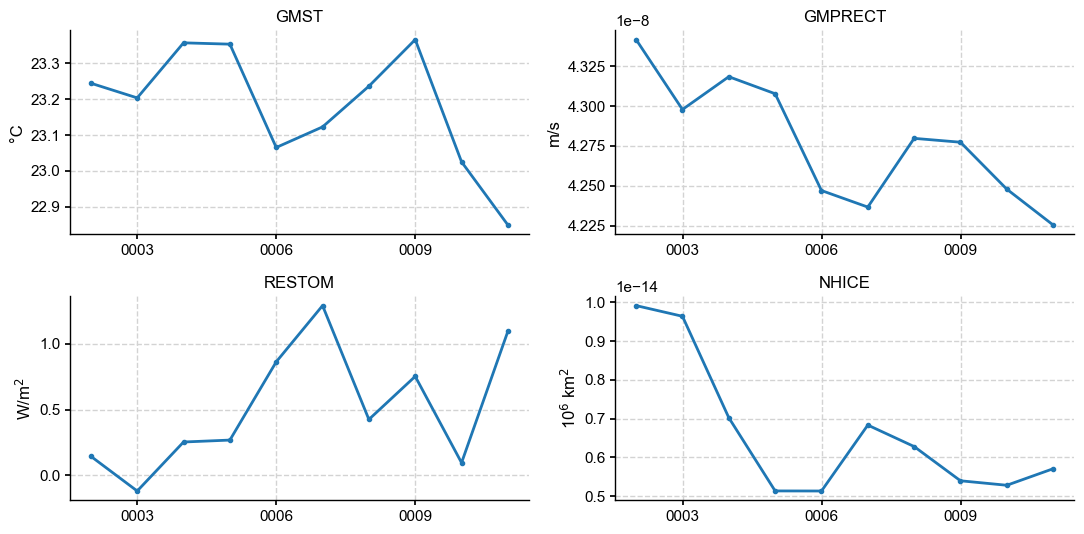

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5.5))
for axi, (key, spell) in zip(axes.ravel(), spells.items()):
    d = case.diags[spell]
    axi.plot(d.time, d.values, marker='o', ms=3)
    axi.set(title=key, ylabel=d.attrs.get('units', ''))
fig.tight_layout()
x4c.showfig(fig)

## Spells with modifiers

`|regrid` puts the field on a regular grid before the spatial step; `.isel(...)`
slices the variable first. The ocean 3-D fields in the sample cover year 1 only.

In [10]:
sst = case.calc('SST ~ TEMP.isel(z_t=0)|regrid(2,2):climo', timespan=(1, 1))
print(dict(sst.sizes))

>>> case.ds["TEMP"] created
>>> Timespan: [0001-01-01 00:00:00, 0001-12-01 00:00:00]


>>> case.diags["SST"] created
{'time': 12, 'lat': 90, 'lon': 180}


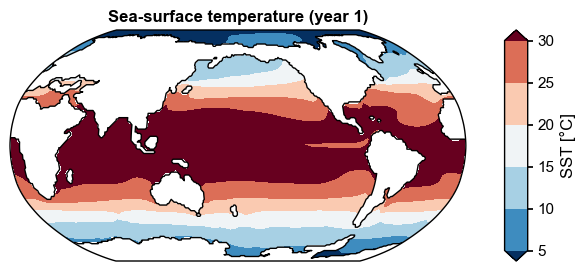

In [11]:
ssh_path = os.path.join(case_dir, 'ocn', 'proc', 'tseries', 'month_1',
                        f'{casename}.pop.h.SSH.000101-000512.nc')
ssv = x4c.open_dataset(ssh_path, comp='ocn', grid='g16', vn='SSH',
                       shift_time=True).x.regrid().x.da.mean('time')

fig, ax = sst.mean('time').x.plot(ssv=ssv, title='Sea-surface temperature (year 1)')
x4c.showfig(fig)

## `zavg`: a depth-weighted average

`|zavg(top, bottom)` averages over a depth range in the units of `z_t` (centimetres
for POP). It folds the layer thicknesses into the area weight, so a following `gm`
gives a true volume-weighted mean rather than a depth-mean of area-means.

The sample keeps only the upper ocean levels, so use a shallow range.

In [12]:
upper = case.calc('T100 ~ TEMP|zavg(0,10000):ann:gm', timespan=(1, 1))
print('volume-mean temperature, top 100 m:', np.round(upper.values, 3),
      upper.attrs.get('units'))

>>> case.ds["TEMP"] already loaded; to reload, run case.load("TEMP", ..., reload=True).
>>> Timespan: [0001-01-01 00:00:00, 0001-12-01 00:00:00]


>>> case.diags["T100"] created
volume-mean temperature, top 100 m: 23.808 °C
